Early stopping at epoch 428


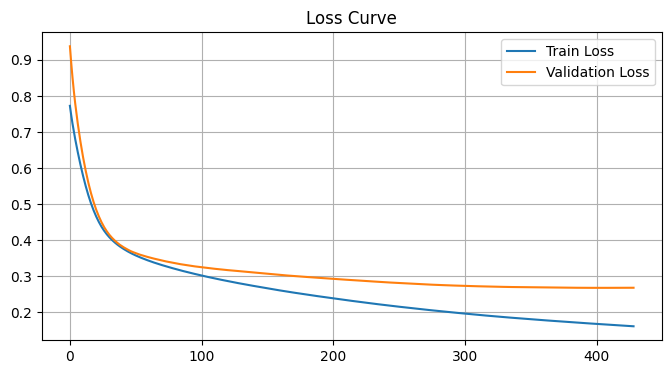

F1: 0.7146401985111662
ROC-AUC: 0.9324842555105712


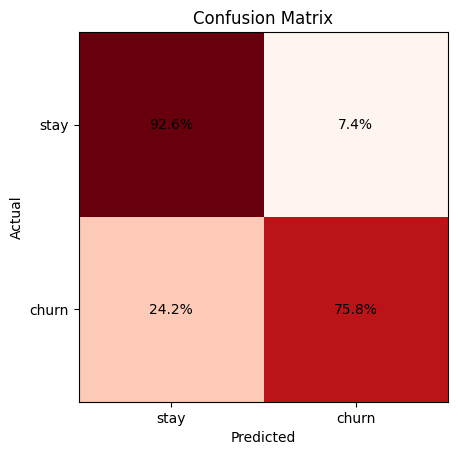

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, log_loss

from src.seed import set_seed
from sklearn import set_config
from src.pipeline.missing_value import CJ_MissingValue, JH_MissingValue, JH_train_stats
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate

# -----------------------
# 0. 환경 설정
# -----------------------
set_seed(42)
set_config(transform_output="pandas")
warnings.filterwarnings("ignore")

# -----------------------
# 1. 데이터 로드
# -----------------------
data = pd.read_excel("../../data/dataset.xlsx").drop_duplicates(subset=["CustomerID"])

drop_cols = ["CustomerID", "IssueIndex", "Silent_Killer", 'Recency_Tenure_Ratio','Stagnant_Loyal','Dormancy_Shock']
data.drop(columns=drop_cols, inplace=True, errors="ignore")

X = data.drop("Churn", axis=1)
y = data["Churn"]

# -----------------------
# 2. train/test 분리
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------
# 3. 결측치 처리
# -----------------------
CJ_SPECS = (
    ("Tenure", "NumberOfAddress", 5),
    ("DaySinceLastOrder", ["PreferedOrderCat", "PreferredLoginDevice"], 10),
    ("OrderCount", ["PreferedOrderCat", "PreferredPaymentMode"], 10),
    ("OrderAmountHikeFromlastYear", "PreferedOrderCat", 3),
)

for col, gps, mgs in CJ_SPECS:
    CJ_MissingValue(X_train, col, gps, mgs, X_train[col].median(), X_test)

jh_stats = JH_train_stats(X_train)
for df in [X_train, X_test]:
    JH_MissingValue(df, **jh_stats)

# -----------------------
# 4. 이상치 + 피처 생성
# -----------------------
cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']

OutlierControl(X_train, cols)
OutlierControl(X_test, cols)

X_train = FeatureCreate(X_train)
X_test = FeatureCreate(X_test, train_monthly_freq_mean=X_train['MonthlyOrderFreq'].mean())

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -----------------------
# 5. 스케일링
# -----------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------
# 6. train / validation 분리
# -----------------------
X_tr_raw, X_val_raw, y_tr_raw, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# -----------------------
# 7. SMOTE
# -----------------------
smote = SMOTE(random_state=42)
X_tr, y_tr = smote.fit_resample(X_tr_raw, y_tr_raw)

X_val = X_val_raw 

# -----------------------
# 8. 모델 설정
# -----------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.2,
    learning_rate_init=0.0001,
    max_iter=1,
    warm_start=True,
    random_state=42
)

# -----------------------
# 9. 학습 + Early Stopping
# -----------------------
train_losses = []
val_losses = []

best_val_loss = np.inf
patience = 30
patience_counter = 0

for epoch in range(1000):

    mlp.partial_fit(X_tr, y_tr, classes=np.unique(y_tr))

    tr_loss = log_loss(y_tr, mlp.predict_proba(X_tr))
    va_loss = log_loss(y_val, mlp.predict_proba(X_val))

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# -----------------------
# 10. Loss 그래프
# -----------------------
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.grid()
plt.show()

# -----------------------
# 11. 평가
# -----------------------
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

best_t = 0.6

y_pred = (y_prob >= best_t).astype(int)

print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# -----------------------
# 12. Confusion Matrix
# -----------------------
cm = confusion_matrix(y_test, y_pred, normalize="true")

plt.imshow(cm, cmap="Reds")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i,j]*100:.1f}%", ha="center", va="center")

labels = ["stay", "churn"]

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()